# Retail Sales EDA — Exploratory Data Analysis

> **Objective:** Analyze retail sales and inventory data to identify revenue drivers, product performance, and sales trends using PostgreSQL, Pandas, and Matplotlib.

## 1. Imports & Configuration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os

In [10]:
load_dotenv()

True

In [11]:
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")

## 2. Database Connection

In [12]:
engine = create_engine(
    f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

## 3. Data Loading

In [13]:
products_df = pd.read_sql(
    "SELECT * FROM products;",
    engine
)

In [14]:
sales_df = pd.read_sql(
    "SELECT * FROM sales;",
    engine
)

In [10]:
products_df.head()

,product_id,name,category,price
0,1,"Fjallraven - Foldsack No. 1 Backpack, Fits 15 ...",men's clothing,109.95
1,2,Mens Casual Premium Slim Fit T-Shirts,men's clothing,22.30
2,3,Mens Cotton Jacket,men's clothing,55.99
3,4,Mens Casual Slim Fit,men's clothing,15.99
4,5,John Hardy Women's Legends Naga Gold & Silver ...,jewelery,695.00


## 4. Data Preparation

### 4.1 Merge products and sales

In [15]:
merged_df = products_df.merge(
    sales_df,
    on="product_id",
    how="left"
)

In [12]:
merged_df.head()

,product_id,name,category,price,sale_id,quantity,sale_date,total_price
0,1,"Fjallraven - Foldsack No. 1 Backpack, Fits 15 ...",men's clothing,109.95,1,1,2026-04-14,109.95
1,1,"Fjallraven - Foldsack No. 1 Backpack, Fits 15 ...",men's clothing,109.95,2,3,2026-04-16,329.85
2,1,"Fjallraven - Foldsack No. 1 Backpack, Fits 15 ...",men's clothing,109.95,3,5,2026-05-03,549.75
3,1,"Fjallraven - Foldsack No. 1 Backpack, Fits 15 ...",men's clothing,109.95,4,5,2026-04-27,549.75
4,1,"Fjallraven - Foldsack No. 1 Backpack, Fits 15 ...",men's clothing,109.95,5,1,2026-04-10,109.95


### 4.2 Type conversions & feature engineering

In [16]:
# Convert sale_date to datetime
merged_df["sale_date"] = pd.to_datetime(merged_df["sale_date"])

# Extract time features
merged_df["month"] = merged_df["sale_date"].dt.month
merged_df["month_name"] = merged_df["sale_date"].dt.month_name()
merged_df["week"] = merged_df["sale_date"].dt.isocalendar().week

print("Date range:", merged_df["sale_date"].min(), "→", merged_df["sale_date"].max())

Date range: 2026-04-09 00:00:00 → 2026-05-09 00:00:00


## 5. Exploratory Data Analysis (EDA)

### 5.1 Dataset Overview

*Questions: Is `sale_date` well-typed? Is `total_price` numeric? Are there unnecessary columns?*

In [17]:
products_df.columns
sales_df.columns
merged_df.columns

Index(['product_id', 'name', 'category', 'price', 'sale_id', 'quantity',
       'sale_date', 'total_price', 'month', 'month_name', 'week'],
      dtype='str')

In [18]:
merged_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 409 entries, 0 to 408
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype        
---  ------       --------------  -----        
 0   product_id   409 non-null    int64        
 1   name         409 non-null    str          
 2   category     409 non-null    str          
 3   price        409 non-null    float64      
 4   sale_id      409 non-null    int64        
 5   quantity     409 non-null    int64        
 6   sale_date    409 non-null    datetime64[s]
 7   total_price  409 non-null    float64      
 8   month        409 non-null    int32        
 9   month_name   409 non-null    str          
 10  week         409 non-null    UInt32       
dtypes: UInt32(1), datetime64[s](1), float64(2), int32(1), int64(3), str(3)
memory usage: 32.5 KB


In [19]:
merged_df.head()
merged_df.tail()

,product_id,name,category,price,sale_id,quantity,sale_date,total_price,month,month_name,week
404,20,DANVOUY Womens T Shirt Casual Cotton Short,women's clothing,12.99,405,2,2026-04-11,25.98,4,April,15
405,20,DANVOUY Womens T Shirt Casual Cotton Short,women's clothing,12.99,406,3,2026-04-12,38.97,4,April,15
406,20,DANVOUY Womens T Shirt Casual Cotton Short,women's clothing,12.99,407,5,2026-05-06,64.95,5,May,19
407,20,DANVOUY Womens T Shirt Casual Cotton Short,women's clothing,12.99,408,1,2026-05-01,12.99,5,May,18
408,20,DANVOUY Womens T Shirt Casual Cotton Short,women's clothing,12.99,409,5,2026-04-23,64.95,4,April,17


In [20]:
merged_df.shape

(409, 11)

### 5.2 Descriptive Statistics

In [21]:
#Statistiques descriptives
merged_df.describe()

,product_id,price,sale_id,quantity,sale_date,total_price,month,week
count,409.000000,409.000000,409.000000,409.000000,409,409.000000,409.000000,409.0
mean,10.897311,180.354817,205.000000,3.056235,2026-04-23 11:08:56,551.900880,4.266504,17.04401
min,1.000000,7.950000,1.000000,1.000000,2026-04-09 00:00:00,7.950000,4.000000,15.0
25%,6.000000,15.990000,103.000000,2.000000,2026-04-15 00:00:00,49.950000,4.000000,16.0
50%,11.000000,56.990000,205.000000,3.000000,2026-04-24 00:00:00,159.960000,4.000000,17.0
75%,15.000000,114.000000,307.000000,4.000000,2026-05-01 00:00:00,545.000000,5.000000,18.0
max,20.000000,999.990000,409.000000,5.000000,2026-05-09 00:00:00,4999.950000,5.000000,19.0
std,5.368683,272.040997,118.212379,1.391242,NaN,959.828781,0.442672,1.355099


The dataset contains 409 sales transactions.

Sales quantities range from 1 to 5 units, with an average quantity of approximately 3 units per transaction.

Product prices show high variability, ranging from 7.95 to 999.99, indicating a mix of low-cost and premium products.

The average transaction revenue is approximately 551.9, although some transactions exceed 4000, suggesting the presence of high-value sales.

### 5.3 Correlation Matrix

In [22]:
corr_matrix = merged_df.corr(numeric_only=True)

corr_matrix

,product_id,price,sale_id,quantity,total_price,month,week
product_id,1.000000,-0.059800,0.997111,-0.027118,-0.042037,0.024951,0.010056
price,-0.059800,1.000000,-0.063684,0.001839,0.876328,0.015724,0.021929
sale_id,0.997111,-0.063684,1.000000,-0.027287,-0.045507,0.026791,0.011980
quantity,-0.027118,0.001839,-0.027287,1.000000,0.273590,-0.004495,-0.016917
total_price,-0.042037,0.876328,-0.045507,0.273590,1.000000,0.005753,-0.006725
month,0.024951,0.015724,0.026791,-0.004495,0.005753,1.000000,0.728118
week,0.010056,0.021929,0.011980,-0.016917,-0.006725,0.728118,1.000000


A strong positive correlation (0.88) exists between product price and total transaction revenue, indicating that higher-priced products contribute significantly to revenue generation.

Quantity sold shows a weaker positive relationship with total revenue, suggesting that product pricing has a stronger impact on revenue than sales volume.

No meaningful correlation was observed between product price and quantity sold.

### 5.4 Data Quality Check

In [29]:
merged_df.isnull().sum()

product_id     0
name           0
category       0
price          0
sale_id        0
quantity       0
sale_date      0
total_price    0
dtype: int64

In [30]:
merged_df.duplicated().sum()

np.int64(0)

In [31]:
merged_df["category"].value_counts()

category
electronics         133
women's clothing    124
jewelery             96
men's clothing       56
Name: count, dtype: int64

## 6. Business Analysis

### 6.1 Top Selling Products
*Quels produits vendent le plus ?*

In [23]:
top_products = (
    merged_df.groupby("name")["quantity"]
    .sum()
    .sort_values(ascending=False)
)

In [43]:
top_products.head(10)

name
Pierced Owl Rose Gold Plated Stainless Steel Double                             96
Acer SB220Q bi 21.5 inches Full HD (1920 x 1080) IPS Ultra-Thin                 88
Solid Gold Petite Micropave                                                     82
Silicon Power 256GB SSD 3D NAND A55 SLC Cache Performance Boost SATA III 2.5    81
BIYLACLESEN Women's 3-in-1 Snowboard Jacket Winter Coats                        77
WD 4TB Gaming Drive Works with Playstation 4 Portable External Hard Drive       77
John Hardy Women's Legends Naga Gold & Silver Dragon Station Chain Bracelet     73
Rain Jacket Women Windbreaker Striped Climbing Raincoats                        72
Opna Women's Short Sleeve Moisture                                              68
Lock and Love Women's Removable Hooded Faux Leather Moto Biker Jacket           65
Name: quantity, dtype: int64

Observation : The top-selling products generated significantly higher sales volumes compared to other products.

    This suggests strong customer demand for these items and indicates potential opportunities for inventory prioritization and targeted marketing.

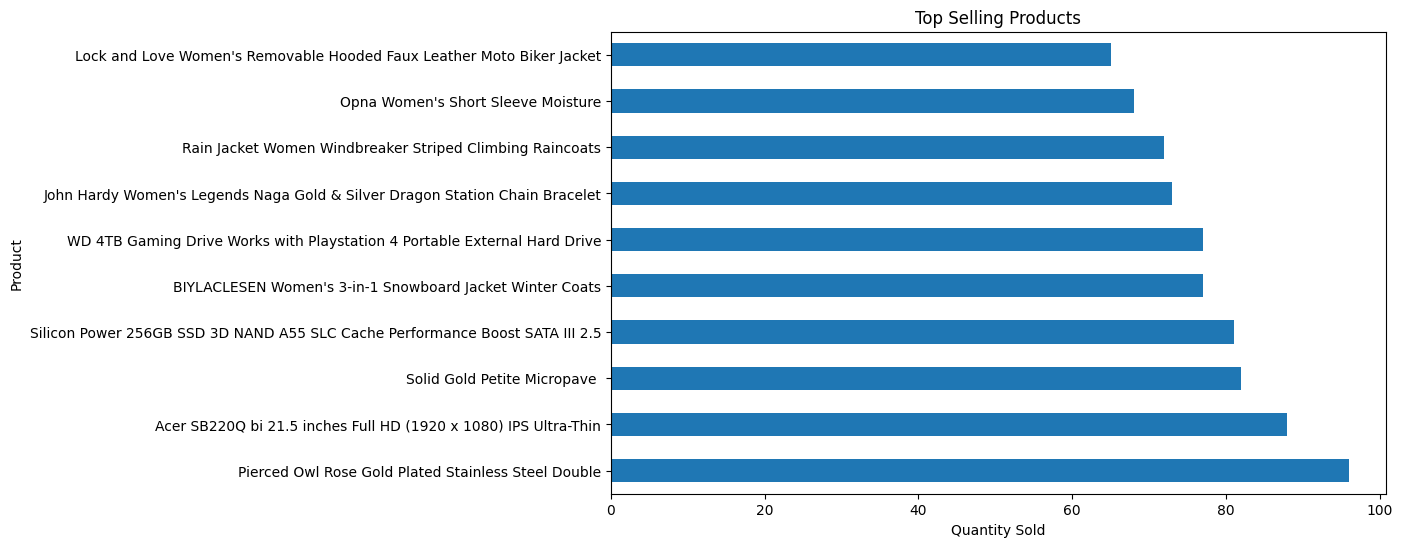

In [24]:
top_products.head(10).plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.show()

### 6.2 Revenue by Product
*Quels produits génèrent le plus de revenu ?*

In [25]:
# Revenue by product
revenue_by_product = merged_df.groupby("name")["total_price"].sum()
revenue_by_product.sort_values(ascending=False).head(10)

name
Samsung 49-Inch CHG90 144Hz Curved Gaming Monitor (LC49HG90DMNXZA) – Super Ultrawide Screen QLED     60999.39
Acer SB220Q bi 21.5 inches Full HD (1920 x 1080) IPS Ultra-Thin                                      52712.00
John Hardy Women's Legends Naga Gold & Silver Dragon Station Chain Bracelet                          50735.00
Solid Gold Petite Micropave                                                                          13776.00
Silicon Power 256GB SSD 3D NAND A55 SLC Cache Performance Boost SATA III 2.5                          8829.00
WD 4TB Gaming Drive Works with Playstation 4 Portable External Hard Drive                             8778.00
SanDisk SSD PLUS 1TB Internal SSD - SATA III 6 Gb/s                                                   6322.00
BIYLACLESEN Women's 3-in-1 Snowboard Jacket Winter Coats                                              4388.23
Fjallraven - Foldsack No. 1 Backpack, Fits 15 Laptops                                                 4068.15
WD 2T

Some products generate high revenue despite lower sales quantities, likely due to higher product prices.

### 6.3 Revenue by Category
*Quelle catégorie performe le mieux ?*

In [26]:
revenue_by_category=merged_df.groupby("category")["total_price"].sum().sort_values(ascending=False)

In [27]:
revenue_by_category.head(10)

category
electronics         140584.39
jewelery             66075.53
women's clothing     10729.41
men's clothing        8338.13
Name: total_price, dtype: float64

Observation: Electronics represent the most profitable category and should be prioritized for inventory management and promotional strategies.

Jewelry products also show strong revenue performance, likely due to higher unit prices.

Clothing categories generate comparatively low revenue, suggesting lower customer demand or lower product pricing.

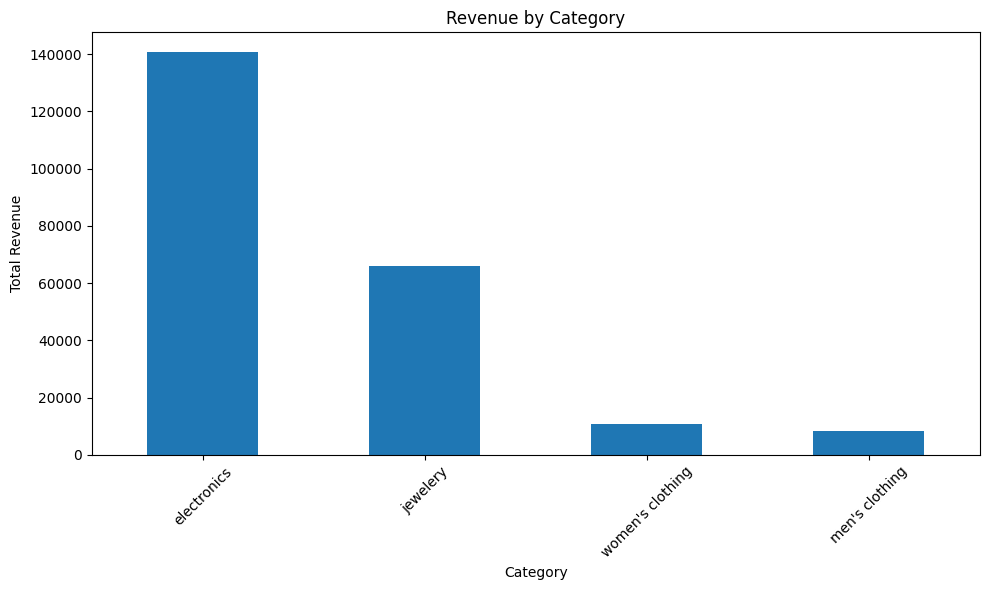

In [28]:
revenue_by_category.plot(kind='bar', figsize=(10, 6))
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 6.4 Daily Sales Trend
*Quels jours génèrent le plus de ventes ?*

In [29]:
daily_sales=merged_df.groupby("sale_date")["total_price"].sum().sort_values(ascending=False)

In [30]:
daily_sales.head(10)

sale_date
2026-04-13    17038.37
2026-04-12    15913.00
2026-04-23    12454.93
2026-04-27    12449.39
2026-04-09    11536.76
2026-04-29    11311.93
2026-05-01    10589.12
2026-04-14    10287.06
2026-04-15     9839.17
2026-05-09     9264.62
Name: total_price, dtype: float64

Observation:   
   Daily sales performance shows noticeable fluctuations, with several peak revenue days exceeding 15,000.

   This indicates periods of increased customer activity that could be linked to promotions, product demand, or seasonal effects.

   Understanding these trends can help businesses optimize marketing campaigns and inventory planning.

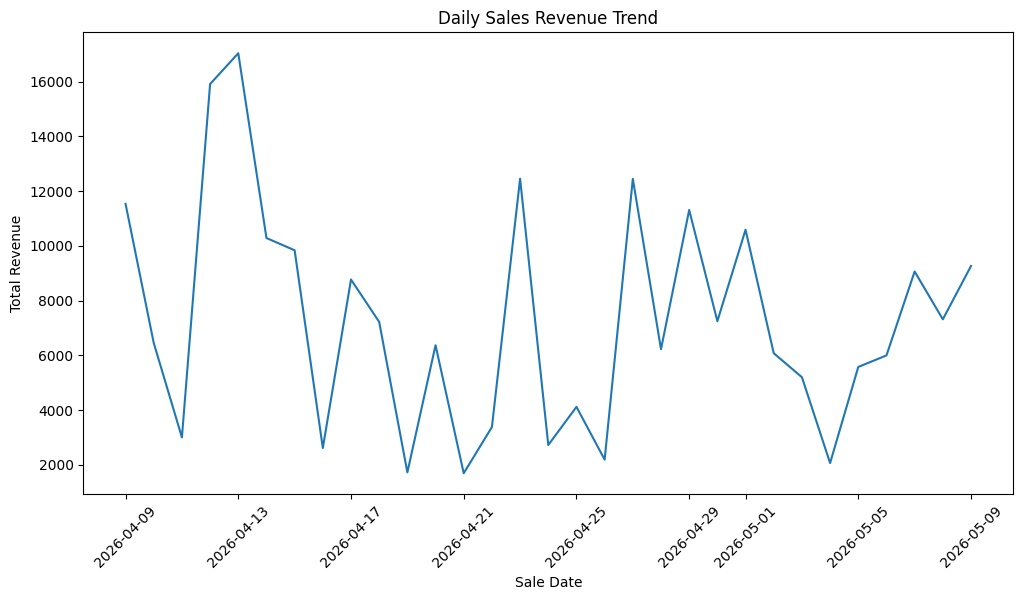

In [31]:
# Daily Sales Trend
index="sale_date"
# convertir en datetime
daily_sales.index = pd.to_datetime(daily_sales.index)

# trier les dates
daily_sales = daily_sales.sort_index()

# créer le graphique
plt.figure(figsize=(12,6))

plt.plot(
    daily_sales.index,
    daily_sales.values
)

# titres et labels
plt.title("Daily Sales Revenue Trend")
plt.xlabel("Sale Date")
plt.ylabel("Total Revenue")

# rotation des dates
plt.xticks(rotation=45)

# affichage
plt.show()

Daily sales revenue shows significant fluctuations over time, with several strong sales peaks observed throughout the period.

The highest revenue levels exceed 15,000, while lower-performing days fall below 3,000.

These variations may indicate changing customer demand, promotional activity, or the influence of high-priced product sales.

### 6.5 Distribution of Quantities Sold
*Quelle est la distribution des quantités vendues ?*

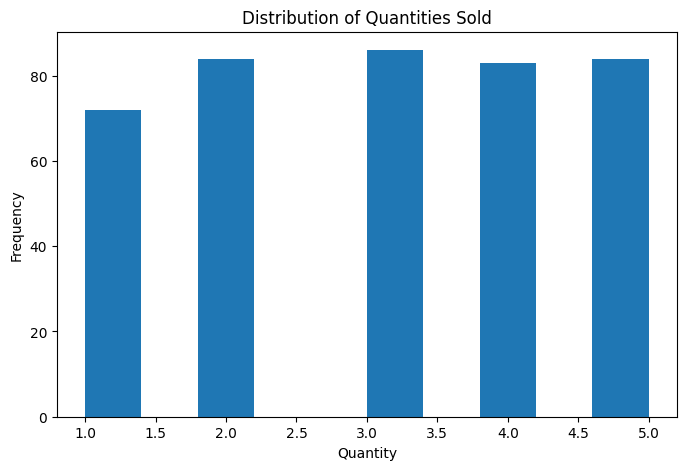

In [32]:
plt.figure(figsize=(8,5))

plt.hist(merged_df["quantity"])

plt.title("Distribution of Quantities Sold")
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

### 6.6 Price vs Revenue
*Les produits chers génèrent-ils plus de revenu ?*

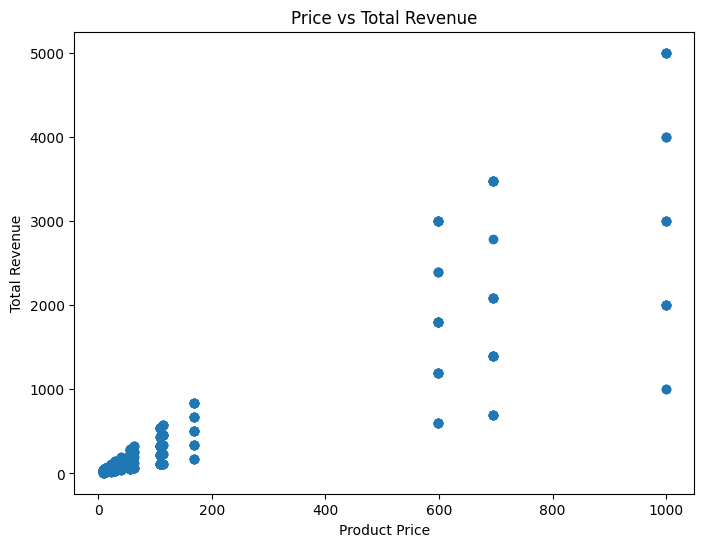

In [33]:
plt.figure(figsize=(8,6))

plt.scatter(
    merged_df["price"],
    merged_df["total_price"]
)

plt.title("Price vs Total Revenue")
plt.xlabel("Product Price")
plt.ylabel("Total Revenue")

plt.show()

## 7. Advanced Time Analysis


## Objective
The purpose of this section is to analyze sales performance over time in order to identify trends, seasonality, and periods of high or low business activity.

Time-based analysis helps businesses:
- understand customer purchasing behavior
- detect revenue trends
- optimize inventory planning
- improve marketing timing strategies



### 7.1 Monthly Revenue

In [34]:
merged_df["month"] = merged_df["sale_date"].dt.month
merged_df["month_name"] = merged_df["sale_date"].dt.month_name()
monthly_revenue = (
    merged_df.groupby("month")["total_price"]
    .sum()
)

monthly_revenue

month
4    164572.91
5     61154.55
Name: total_price, dtype: float64

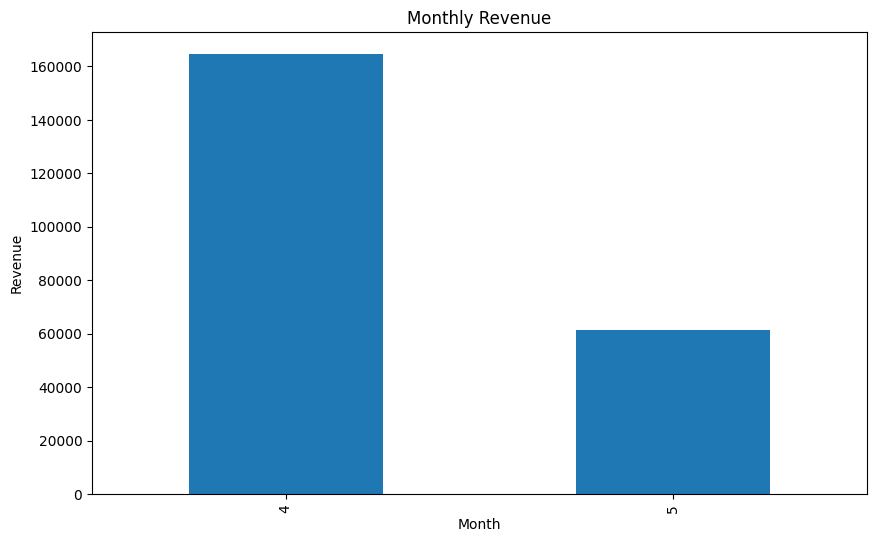

In [35]:
## Visualisation
monthly_revenue.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

### 7.2 Weekly Revenue Trend

In [36]:
merged_df["week"] = (
    merged_df["sale_date"]
    .dt.isocalendar()
    .week
)

weekly_revenue = (
    merged_df.groupby("week")["total_price"]
    .sum()
)

weekly_revenue

week
15    36906.55
16    57497.08
17    32933.30
18    59105.28
19    39285.25
Name: total_price, dtype: float64

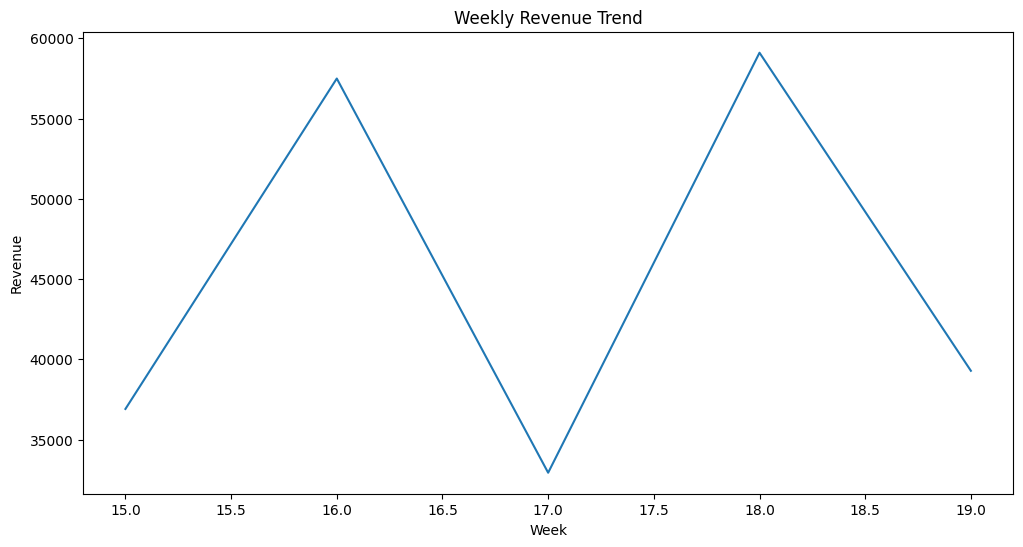

In [37]:
## Visualisation
weekly_revenue.plot(
    kind="line",
    figsize=(12,6)
)

plt.title("Weekly Revenue Trend")
plt.xlabel("Week")
plt.ylabel("Revenue")

plt.show()

## 8. KPI Metrics

### KPI 1 — Total Revenue

In [38]:
total_revenue = merged_df["total_price"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 225727.46


### KPI 2 — Total Sales Transactions

In [39]:
total_sales = merged_df["sale_id"].count()

print("Total Sales:", total_sales)

Total Sales: 409


### KPI 3 — Average Order Value

In [40]:
average_order_value = merged_df["total_price"].mean()

print("Average Order Value:", average_order_value)

Average Order Value: 551.900880195599


### KPI 4 — Best Category

In [41]:
best_category = (
    merged_df.groupby("category")["total_price"]
    .sum()
    .idxmax()
)

print("Best Category:", best_category)

Best Category: electronics


### KPI 5 — Best Product

In [42]:
best_product = (
    merged_df.groupby("name")["total_price"]
    .sum()
    .idxmax()
)

print("Best Product:", best_product)

Best Product: Samsung 49-Inch CHG90 144Hz Curved Gaming Monitor (LC49HG90DMNXZA) – Super Ultrawide Screen QLED 


The business generated substantial revenue across the analyzed period.

Electronics emerged as the top-performing category, while several products significantly outperformed others in revenue contribution.

Average transaction value indicates strong customer purchasing behavior.

# Insights & Recommendations

## Key Insights

- Electronics generate the highest revenue.
- Sales fluctuate significantly over time.
- Product price strongly impacts total revenue.
- Most transactions contain small quantities.

## Business Recommendations

- Prioritize electronics inventory.
- Increase marketing during high-performing periods.
- Monitor low-performing categories.
- Focus on high-value products.

# Conclusion

This project analyzed retail sales and inventory data using PostgreSQL, Pandas, and Matplotlib.

The analysis identified key revenue drivers, sales trends, and category performance.

The project demonstrates skills in:
- SQL
- Data analysis
- Data visualization
- Business analytics
- Data storytelling

# CSV Export Reports

In [43]:
merged_df.to_csv(
    "reports/cleaned_sales_data.csv",
    index=False
)

OSError: Cannot save file into a non-existent directory: 'reports'